# PREPARATION

In [10]:
import pandas as pd
import os

data_folder = './datasets/'

# Map 2020's old column names to the modern 2021-2024 names (2020's missing 'Have')
rename_map = {
    'LanguageWorkedWith': 'LanguageHaveWorkedWith',
    'DatabaseWorkedWith': 'DatabaseHaveWorkedWith',
    'PlatformWorkedWith': 'PlatformHaveWorkedWith',
    'WebframeWorkedWith': 'WebframeHaveWorkedWith',
    'MiscTechWorkedWith': 'MiscTechHaveWorkedWith'
}

# Select key columns
target_columns = [
    'MainBranch',
    'DevType',
    'LanguageHaveWorkedWith', 
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith',
    'ToolsTechHaveWorkedWith',
    *rename_map.keys()
]

# Filter key columns
all_years_data = []
for filename in os.listdir(data_folder):
    filepath = os.path.join(data_folder, filename)
    df_year = pd.read_csv(filepath, usecols=lambda c: c in target_columns, low_memory=False)
    df_year = df_year.rename(columns=rename_map)
    all_years_data.append(df_year)

df = pd.concat(all_years_data, ignore_index=True)

print(f"Total rows loaded: {len(df)}")

# Isolate tech columns for baskets creation
tech_columns = [
    'LanguageHaveWorkedWith', 
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith',
    'ToolsTechHaveWorkedWith'
]

for col in tech_columns:
    df[col] = df[col].fillna('') + ';'

# Create a master column of one's entire stack
df['Full_Stack'] = df[tech_columns].sum(axis=1)

# Create & clean transactions
transactions_raw = df['Full_Stack'].str.strip(';').str.split(';')
df['Transaction_Basket'] = [
    [tech.strip() for tech in stack if tech.strip() != ''] 
    for stack in transactions_raw
]

# Filter by profession, removing hobbyists
df = df[df['MainBranch'].str.contains('developer by profession', na=False, case=False)]
df = df[df['Transaction_Basket'].map(len) > 0]
df = df.reset_index(drop=True)

# Check
print(f"Total valid developer transactions: {len(df['Transaction_Basket'])}")
print("\nFirst 3 transactions:")
for i in range(3):
    print(df['Transaction_Basket'].iloc[i])

Total rows loaded: 375789
Total valid developer transactions: 274135

First 3 transactions:
['C#', 'HTML/CSS', 'JavaScript', 'Elasticsearch', 'Microsoft SQL Server', 'Oracle', 'Windows', 'ASP.NET', 'ASP.NET Core', '.NET', '.NET Core']
['JavaScript', 'Swift', 'iOS', 'React Native']
['HTML/CSS', 'Ruby', 'SQL', 'MySQL', 'PostgreSQL', 'Redis', 'SQLite', 'AWS', 'Docker', 'Linux', 'MacOS', 'Windows', 'Ruby on Rails', 'Ansible']


Successfully merged 5 years worth of data into one dataframe, string splitting worked (languages [javascript...], databases [postgreSQL], framework [Laravel...] in a single basket, which apiory could work with)

Generating Stack Size Distribution Chart...


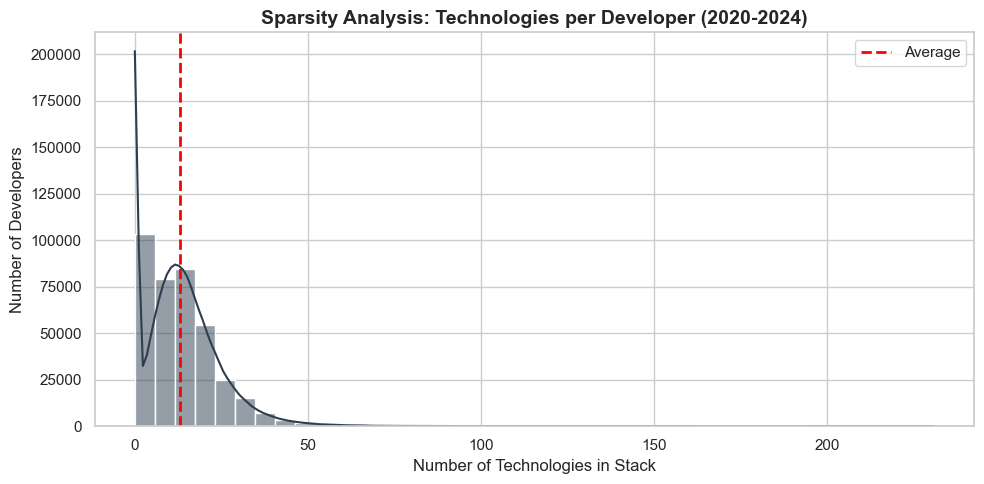


Generating Top 20 Technologies Chart...


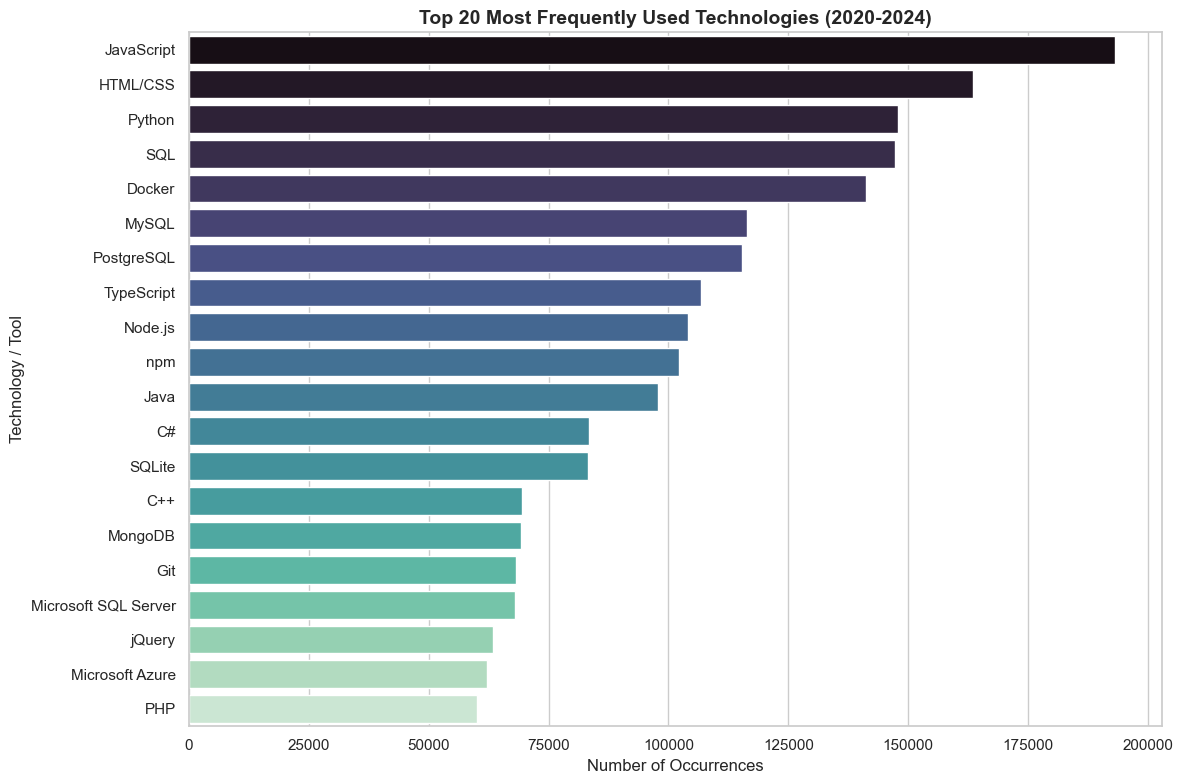


--- Quick Stats for Final Report ---
Total unique technologies discovered: 270
Average stack size: 12.98 technologies per developer


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

transactions = df['Transaction_Basket'].tolist()
sns.set_theme(style="whitegrid")

# ==========================================
# CHART 1: Sparsity Analysis (Stack Sizes)
# Count how many technologies are in each developer's stack
# ==========================================

stack_sizes = [len(transaction) for transaction in transactions]

plt.figure(figsize=(10, 5))
sns.histplot(stack_sizes, bins=40, kde=True, color='#2c3e50')
plt.title('Sparsity Analysis - Technologies per Developer (2020-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Technologies in Stack', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)
plt.axvline(sum(stack_sizes)/len(stack_sizes), color='red', linestyle='dashed', linewidth=2, label='Average')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average stack size: {sum(stack_sizes)/len(stack_sizes):.2f} technologies per developer")

# ==========================================
# CHART 2: Frequency Analysis (Top 20 Tech)
# Flatten our list of lists into one giant list of all technologies used
# ==========================================

all_tech = [tech.strip() for transaction in transactions for tech in transaction]

# Count the occurrences of each technology
tech_counts = Counter(all_tech)
top_20 = tech_counts.most_common(20)

# Extract names and frequencies for the chart
tech_names = [x[0] for x in top_20]
tech_freq = [x[1] for x in top_20]

plt.figure(figsize=(12, 8))
sns.barplot(x=tech_freq, y=tech_names, hue=tech_names, palette='mako', legend=False)
plt.title('Top 20 Most Frequently Used Technologies (2020-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Technology / Tool', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Total unique technologies: {len(tech_counts)}")

# Print some quick stats for your report
print(f"\n--- Quick Stats for Final Report ---")
print(f"Total unique technologies discovered: {len(tech_counts)}")


Generating Role-Specific Comparison Chart...


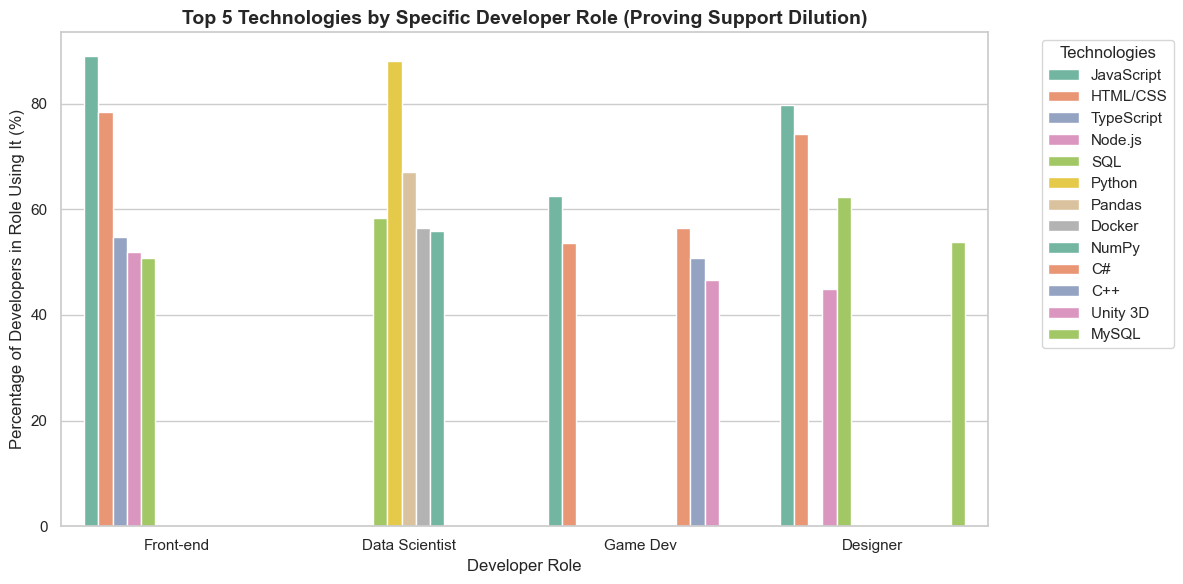

In [ ]:
# ==========================================
# CHART 3: Top Tech by Developer Role (Micro Analysis Setup)
# ==========================================
print("\nGenerating Role-Specific Comparison Chart...")

# Stack Overflow often allows multiple roles (e.g., "Developer, front-end; Developer, back-end"). 
# To keep this chart clean, let's just look at people who strongly identified with one primary role category.
# We will check if the string contains these keywords.
roles_to_check = {
    'Front-end': 'front-end',
    'Data Scientist': 'data scientist',
    'Mobile': 'mobile',
    'Game Dev': 'game or graphics',
    'Designer': 'designer'
}

role_tech_data = []

for role_name, keyword in roles_to_check.items():
    # Filter the dataframe for this specific role
    df_role = df[df['DevType'].str.contains(keyword, na=False, case=False)]
    
    # Flatten their specific baskets
    role_transactions = df_role['Transaction_Basket'].tolist()
    role_all_tech = [tech.strip() for transaction in role_transactions for tech in transaction]
    
    # Get their top 5
    role_top_5 = Counter(role_all_tech).most_common(5)
    
    # Save for plotting
    for tech, count in role_top_5:
        # Calculate percentage to make it fair (since there are more front-end devs than game devs)
        percentage = (count / len(df_role)) * 100 
        role_tech_data.append({'Role': role_name, 'Technology': tech, 'Usage (%)': percentage})

# Convert to DataFrame for Seaborn
df_role_chart = pd.DataFrame(role_tech_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_role_chart, x='Role', y='Usage (%)', hue='Technology', palette='Set2')
plt.title('Top 5 Technologies by Specific Developer Role (Proving Support Dilution)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Developers in Role Using It (%)', fontsize=12)
plt.xlabel('Developer Role', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Technologies")
plt.tight_layout()
plt.show()

In [14]:
print(df['DevType'].value_counts())

DevType
Developer, full-stack                                                                                                                                                                                                                                                                                                                                                                                                                  60772
Developer, back-end                                                                                                                                                                                                                                                                                                                                                                                                                    35949
Developer, front-end                                                                                                                  

In [15]:
print(df['DevType'].unique())

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                'Developer, desktop or enterprise applications;Developer, full-stack',
                                                                                                                                                                                                                                                                                                                                                                                             'Developer, full-stack;Developer, mobile',
                                                                                                                                          